# Отчёт по бейзлайн-моделям для предсказания дефолта по кредиту

## Проделанная работа

В рамках baseline-экспериментов была выполнена следующая работа:

**Загрузка и подготовка данных** из предобработанного датасета `LoanDefaultPredictionDatasetPROC.csv`
**Разделение выборки**: train (70%), validation (15%), test (15%) со стратификацией по целевому признаку
**Обучение трёх моделей** с подбором базовых гиперпараметров
**Оценка качества** моделей на валидационной выборке
**Сохранение метрик и визуализаций** для последующего анализа

## Бейзлайн-модели

| Модель | Ключевые параметры |
|--------|---------------------|
| **Logistic Regression** | `penalty='l2'`, `class_weight='balanced'`, `solver='saga'`, стандартизация признаков |
| **Decision Tree** | `max_depth=15`, `min_samples_split=100`, `min_samples_leaf=50`, `class_weight='balanced'`, `criterion='entropy'` |
| **Random Forest** | `n_estimators=100`, `min_samples_split=100`, `min_samples_leaf=50`, `class_weight='balanced'` |

## Оцениваемые метрики

**Accuracy** (точность)<br>
**Precision** (точность по классу дефолта)<br>
**Recall** (полнота по классу дефолта)<br>
**F1-score** (гармоническое среднее)<br>
**ROC-AUC** (площадь под ROC-кривой)<br>

## Сохранённые артефакты


Метрики моделей `/artifacts/Baselines/runsBase.csv` <br>
Матрицы ошибок `/artifacts/Baselines/figures` <br>
ROC-кривые `/artifacts/Baselines/figures` <br>
PR-кривые `/artifacts/Baselines/figures` <br>
Настройки baseline моделей `/configs/baseline_config.json`

## Результаты моделей (валидационная выборка)

| Модель | Accuracy | F1 | Precision | Recall | ROC-AUC |
|--------|----------|-----|-----------|--------|---------|
| **Random Forest** | 0.744 | 0.353 | 0.250 | 0.603 | 0.752 |
| **Logistic Regression** | 0.674 | 0.331 | 0.217 | 0.693 | 0.749 |
| **Decision Tree** | 0.657 | 0.289 | 0.190 | 0.601 | 0.683 |

## Краткий вывод

1. **Random Forest показал лучшее качество** по `F1` `ROC-AUC`, что ожидаемо для ансамблевого метода.

2. **Logistic Regression** продемонстрировала самый высокий `Recall`— модель лучше выявляет потенциальных дефолтников, но платит за это низкой `Precision`.

3. **Все модели страдают от дисбаланса классов** F1-метрики для класса "дефолт" остаются низкими (0.29-0.35).

4. **Decision Tree** показала наихудшие результаты, что объясняется отсутствием ансамблирования и склонностью к переобучению даже с ограничениями глубины.

## Гипотезы по улучшению моделей
Для улучшения качества необходимо:
- Провести подбор гиперпараметров (GridSearch/Optuna)
- Рассмотреть нейронные сети (MLP)
- Рассмотреть градиентный бустинг (XGBoost, LightGBM, CatBoost)
- Провести балансировку классов (SMOTETomek)

In [ ]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    confusion_matrix
)

In [40]:
df = pd.read_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasMortgage_Yes,HasDependents_No,HasDependents_Yes,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,1,0,1,0,0,0,0,1,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,1,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,1,1,0,0,0,0,1,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,1,0,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,1,1,0,0,0,0,1,0


In [41]:
X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Размеры выборок:")
print("train:", X_train.shape)
print("val:", X_val.shape)
print("test:", X_test.shape)

print("\nРаспределение классов (train):")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов (val):")
print(y_val.value_counts(normalize=True))
print("\nРаспределение классов (test):")
print(y_test.value_counts(normalize=True))

Размеры выборок:
train: (178742, 31)
val: (38302, 31)
test: (38303, 31)

Распределение классов (train):
Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

Распределение классов (val):
Default
0    0.88387
1    0.11613
Name: proportion, dtype: float64

Распределение классов (test):
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64


In [42]:
baseLogReg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                penalty="l2",
                C=1.0,         
                solver="saga", 
                random_state=42,
                class_weight="balanced",
                max_iter=1000,
                tol=1e-4,
            ),
        ),
    ]
)

baseDecisionTree = DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",    
        max_depth=15,                
        min_samples_split=100,       
        min_samples_leaf=50,         
        criterion="entropy"             
    )

baseRandomForest = RandomForestClassifier(
        n_estimators=100,
        min_samples_split=100,
        min_samples_leaf=50,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

baseLogReg.fit(X_train, y_train)
baseDecisionTree.fit(X_train, y_train)
baseRandomForest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=50,
                       min_samples_split=100, n_jobs=-1, random_state=42)

In [43]:
def compute_metrics(y_true, y_pred, y_proba=None):
    methrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_val, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_val, y_pred, zero_division=0)),
    }
    if y_proba is None:
        methrics["roc_auc"] = None
    else:
        try:
            methrics["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            methrics["roc_auc"] = None
    return methrics

def evaluate_on_test(model, X_test, y_test, label):
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    methrics = compute_metrics(y_test, pred, proba)
    methrics["model"] = label
    return methrics

runsBase = []

runsBase.append(evaluate_on_test(baseLogReg, X_val, y_val, "baseLogReg"))
runsBase.append(evaluate_on_test(baseDecisionTree, X_val, y_val, "baseDecisionTree"))
runsBase.append(evaluate_on_test(baseRandomForest, X_val, y_val, "baseRandomForest"))

for i in runsBase:
    print(i)

print("LogReg", classification_report(y_val,  baseLogReg.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("DecisionTree", classification_report(y_val,  baseDecisionTree.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')
print("RandomForest", classification_report(y_val,  baseRandomForest.predict(X_val), target_names=["Не дефолт", "Дефолт"]), sep='\n')


{'accuracy': 0.6744556420030285, 'f1': 0.3307390907627073, 'Precision': 0.21723189734188816, 'Recall': 0.6926708633093526, 'roc_auc': 0.7485520769890851, 'model': 'baseLogReg'}
{'accuracy': 0.656858649678868, 'f1': 0.2890679937253205, 'Precision': 0.19032694636370112, 'Recall': 0.6007194244604317, 'roc_auc': 0.6828050681980556, 'model': 'baseDecisionTree'}
{'accuracy': 0.7439820374915148, 'f1': 0.35342212844520643, 'Precision': 0.25004665049449526, 'Recall': 0.6025179856115108, 'roc_auc': 0.7524497320380831, 'model': 'baseRandomForest'}
LogReg
              precision    recall  f1-score   support

   Не дефолт       0.94      0.67      0.78     33854
      Дефолт       0.22      0.69      0.33      4448

    accuracy                           0.67     38302
   macro avg       0.58      0.68      0.56     38302
weighted avg       0.86      0.67      0.73     38302

DecisionTree
              precision    recall  f1-score   support

   Не дефолт       0.93      0.66      0.77     33854
 

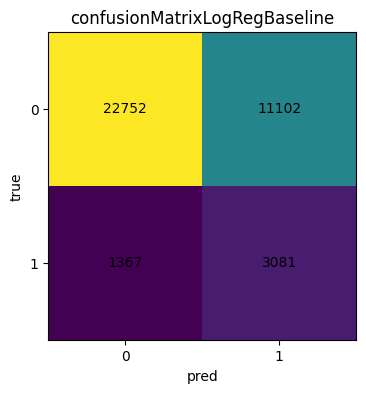

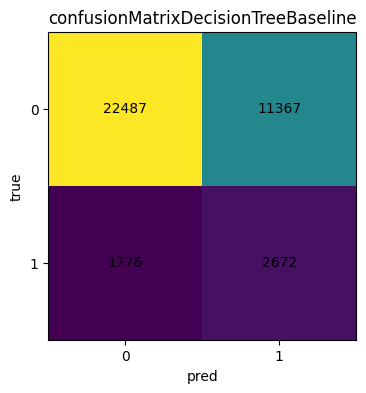

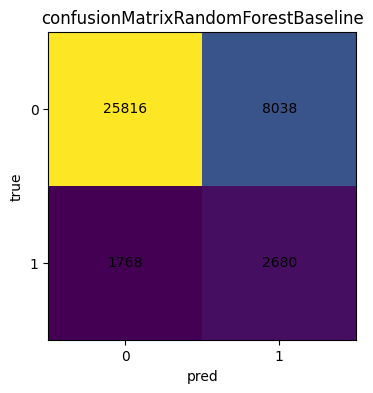

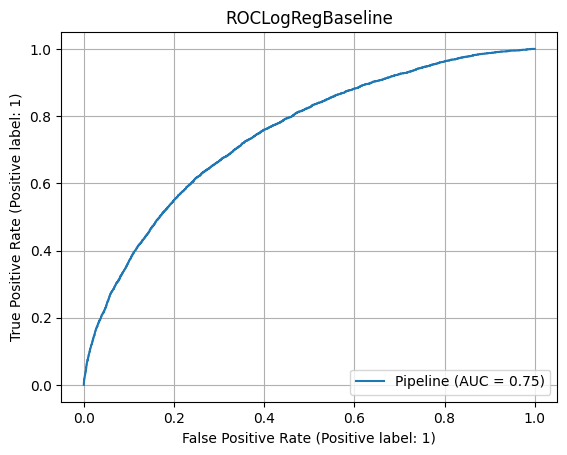

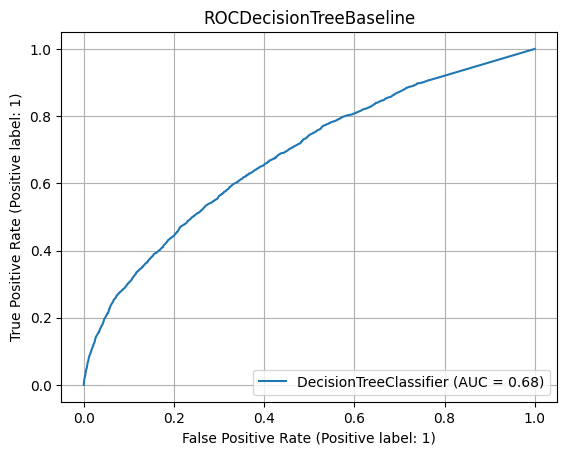

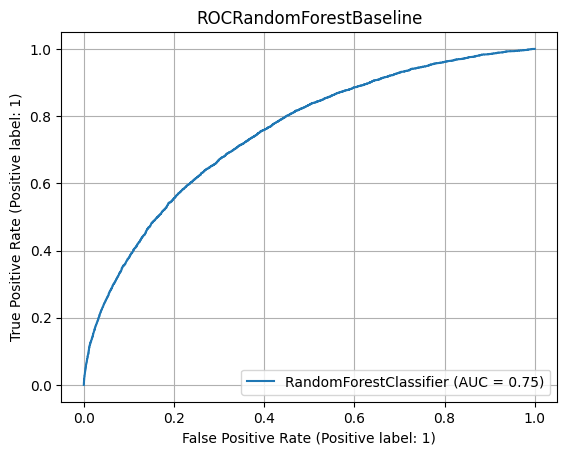

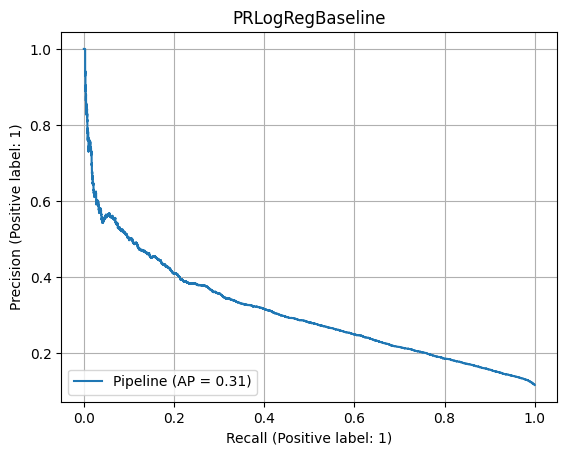

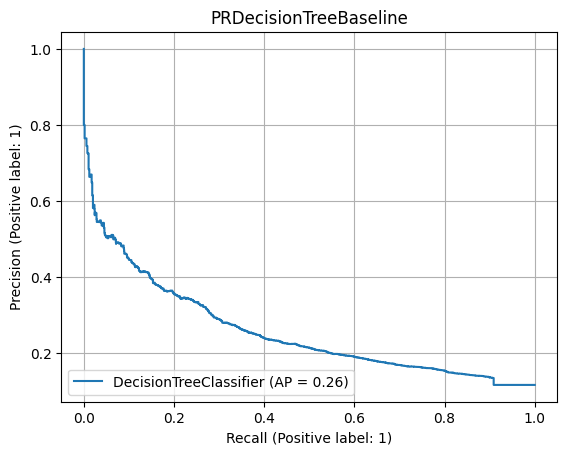

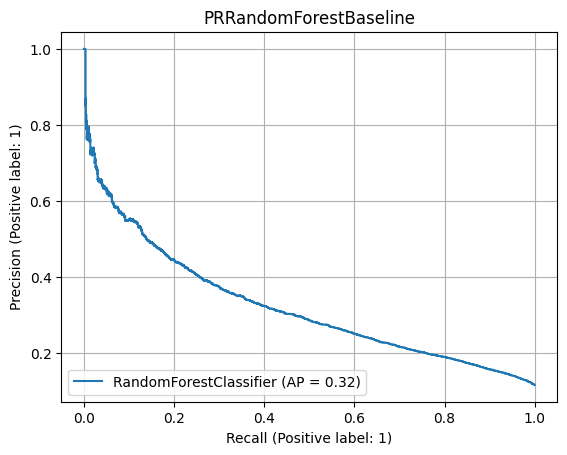

In [44]:
#рисует матрицу ошибок
def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("pred")
    plt.ylabel("true")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    pth = f"../artifacts/Baselines/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

#рисует roc кривую
def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/Baselines/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

def plot_prd(model, X_test, y_test, title):
    if not hasattr(model, "predict_proba"):
        print("PrecisionRecallDisplay: модель не поддерживает predict_proba")
        return
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.grid(True)
    pth = f"../artifacts/Baselines/figures/{title}.png"
    plt.savefig(pth)
    plt.show()

plot_confusion(y_val, baseLogReg.predict(X_val), "confusionMatrixLogRegBaseline")
plot_confusion(y_val, baseDecisionTree.predict(X_val), "confusionMatrixDecisionTreeBaseline")
plot_confusion(y_val, baseRandomForest.predict(X_val), "confusionMatrixRandomForestBaseline")

plot_roc(baseLogReg, X_val, y_val, "ROCLogRegBaseline")
plot_roc(baseDecisionTree, X_val, y_val, "ROCDecisionTreeBaseline")
plot_roc(baseRandomForest, X_val, y_val, "ROCRandomForestBaseline")

plot_prd(baseLogReg, X_val, y_val, "PRLogRegBaseline")
plot_prd(baseDecisionTree, X_val, y_val, "PRDecisionTreeBaseline")
plot_prd(baseRandomForest, X_val, y_val, "PRRandomForestBaseline")

In [45]:
def save_metrics_to_csv(metrics_list, filepath):
    # Создаём DataFrame из списка
    df_metrics = pd.DataFrame(metrics_list)
    
    # Сортируем по ROC-AUC (опционально)
    df_metrics = df_metrics.sort_values('f1', ascending=False)
        
    # Сохраняем в CSV
    df_metrics.to_csv(filepath, index=False)
    print("ГОТОВО!")

save_metrics_to_csv(runsBase, "../artifacts/Baselines/runsBase.csv")

ГОТОВО!


In [ ]:
# Конфигурация эксперимента
EXPERIMENT_CONFIG = {
    "data_path": "/data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv",
    "target_column": "Default",
    "random_state": 42,
    "test_size": 0.3,
    "val_size": 0.5,  
    "stratify": True
}

# Конфигурация Logistic Regression (Pipeline)
LOGREG_CONFIG = {
    "model_name": "LogisticRegressionBaseline",
    "scaler": {
        "name": "StandardScaler",
        "params": {
            "copy": True,
            "with_mean": True,
            "with_std": True
        }
    },
    "logreg": {
        "penalty": "l2",
        "C": 1.0,
        "solver": "saga",
        "random_state": 42,
        "class_weight": "balanced",
        "max_iter": 1000,
        "tol": 1e-4,
        "fit_intercept": True,
        "dual": False
    }
}

# Конфигурация Decision Tree
DECISION_TREE_CONFIG = {
    "model_name": "DecisionTreeBaseline",
    "params": {
        "random_state": 42,
        "class_weight": "balanced",
        "max_depth": 15,
        "min_samples_split": 100,
        "min_samples_leaf": 50,
        "criterion": "entropy",
        "splitter": "best",
        "min_weight_fraction_leaf": 0.0,
        "max_features": None,
        "max_leaf_nodes": None,
        "min_impurity_decrease": 0.0,
        "ccp_alpha": 0.0
    }
}

# Конфигурация Random Forest
RANDOM_FOREST_CONFIG = {
    "model_name": "RandomForestBaseline",
    "params": {
        "n_estimators": 100,
        "min_samples_split": 100,
        "min_samples_leaf": 50,
        "class_weight": "balanced",
        "n_jobs": -1,
        "random_state": 42,
        "criterion": "gini",
        "max_depth": None,
        "min_samples_leaf": 50,
        "min_samples_split": 100,
        "max_features": "sqrt",
        "max_leaf_nodes": None,
        "min_impurity_decrease": 0.0,
        "bootstrap": True,
        "oob_score": False,
        "verbose": 0,
        "warm_start": False,
        "ccp_alpha": 0.0,
        "max_samples": None
    }
}

# Сводный словарь со всеми моделями
ALL_MODELS_CONFIG = {
    "experiment": EXPERIMENT_CONFIG,
    "models": {
        "logreg": LOGREG_CONFIG,
        "decision_tree": DECISION_TREE_CONFIG,
        "random_forest": RANDOM_FOREST_CONFIG
    }
}

# Сохраняем общий конфиг
with open("../configs/baseline_config.json", "w") as f:
    json.dump(ALL_MODELS_CONFIG, f, indent=4)